<a href="https://colab.research.google.com/github/aravindchandra/Aravind_INFO5731_Spring2026/blob/main/Adari_Aravind_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [7]:
import pandas as pd
import string
import nltk
from collections import Counter

df = pd.read_csv('semantic_scholar_abstracts_cleaned (1).csv')
df_100 = df.head(100).copy()

# Preprocessing the function for N-gram analysis
def get_tokens(text):
    if not isinstance(text, str):
        return []
    # Removed punctuation and converted to lowercase
    text = text.translate(str.maketrans('', '', string.punctuation)).lower()
    # Spliting words
    return text.split()

df_100['tokens'] = df_100['abstract'].apply(get_tokens)

# **(1) Count the frequency of all the N-grams (N=3 and N=2)**

In [3]:
def generate_ngrams(tokens, n):
    ngrams = []
    for i in range(len(tokens) - n + 1):
        ngrams.append(tuple(tokens[i:i+n]))
    return ngrams

all_bigrams = []
all_trigrams = []

for tokens in df_100['tokens']:
    all_bigrams.extend(generate_ngrams(tokens, 2))
    all_trigrams.extend(generate_ngrams(tokens, 3))

bigram_freq = Counter(all_bigrams)
trigram_freq = Counter(all_trigrams)

print("--- Top 10 Bigrams Frequency ---")
print(bigram_freq.most_common(10))
print("\n--- Top 10 Trigrams Frequency ---")
print(trigram_freq.most_common(10))

--- Top 10 Bigrams Frequency ---
[(('of', 'the'), 128), (('machine', 'learning'), 108), (('in', 'the'), 91), (('based', 'on'), 46), (('and', 'the'), 46), (('on', 'the'), 41), (('in', 'this'), 39), (('with', 'the'), 36), (('this', 'paper'), 31), (('this', 'study'), 30)]

--- Top 10 Trigrams Frequency ---
[(('in', 'this', 'paper'), 17), (('a', 'machine', 'learning'), 14), (('of', 'machine', 'learning'), 13), (('machine', 'learning', 'algorithms'), 12), (('based', 'on', 'the'), 12), (('machine', 'learning', 'models'), 11), (('support', 'vector', 'machine'), 10), (('the', 'use', 'of'), 10), (('machine', 'learning', 'techniques'), 9), (('and', 'machine', 'learning'), 9)]


# **(2) Calculate probabilities for all bigrams: count(w1 w2) / count(w1)**

In [4]:
# Get unigram counts first
all_unigrams = [word for tokens in df_100['tokens'] for word in tokens]
unigram_counts = Counter(all_unigrams)

bigram_probabilities = {}
for bg, count in bigram_freq.items():
    w1 = bg[0]
    # P(w2 | w1) = count(w1 w2) / count(w1)
    probability = count / unigram_counts[w1]
    bigram_probabilities[bg] = probability

print("\n--- Sample Bigram Probabilities (First 5) ---")
for bg in list(bigram_probabilities.keys())[:5]:
    print(f"P({bg[1]} | {bg[0]}) = {bigram_probabilities[bg]:.4f}")


--- Sample Bigram Probabilities (First 5) ---
P(the | in) = 0.2209
P(era | the) = 0.0017
P(of | era) = 0.5000
P(burgeoning | of) = 0.0015
P(electric | burgeoning) = 1.0000


# **(3) Extract Noun Phrases and Calculate Relative Probabilities**

In [5]:
import pandas as pd
import nltk
from collections import Counter

try:
    nltk.download('punkt')
    nltk.download('punkt_tab')
    nltk.download('averaged_perceptron_tagger')
    nltk.download('averaged_perceptron_tagger_eng')
except:
    pass

# 1. Loaded the dataset and selected the first 100 reviews
df = pd.read_csv('semantic_scholar_abstracts_cleaned (1).csv')
df_100 = df.head(100).copy()

# 2. Defining Noun Phrase Extraction Logic
# I use a standard grammar for Noun Phrases: (Optional Determiner) + (Adjectives) + (Nouns)
grammar = r"NP: {<DT>?<JJ>*<NN.*>+}"
cp = nltk.RegexpParser(grammar)

def get_noun_phrases(text):
    if not isinstance(text, str):
        return []
    # Tokenize and Tag parts of speech
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    # Parse based on grammar
    tree = cp.parse(pos_tags)
    nps = []
    for subtree in tree.subtrees():
        if subtree.label() == 'NP':
            # Join words in the noun phrase and convert to lowercase
            np_text = " ".join([word for word, tag in subtree.leaves()])
            nps.append(np_text.lower())
    return nps

# Extraction Apply to the first 100 abstracts
df_100['noun_phrases'] = df_100['abstract'].apply(get_noun_phrases)

# 3. Calculate Frequencies
# Count NP frequency per review
np_freq_per_doc = [Counter(nps) for nps in df_100['noun_phrases']]

# Identify all unique noun phrases across the 100 reviews
all_unique_nps = sorted(list(set([np for sublist in df_100['noun_phrases'] for np in sublist])))

# Find the maximum frequency of each specific NP across the whole dataset (100 reviews)
max_freq_dict = {}
for np in all_unique_nps:
    max_f = max([doc_counts[np] for doc_counts in np_freq_per_doc])
    max_freq_dict[np] = max_f

# 4. Calculate Relative Probabilities
# Formula: frequency(np) / max_frequency(np)
rel_prob_matrix = []
for doc_counts in np_freq_per_doc:
    row = {np: (doc_counts[np] / max_freq_dict[np] if max_freq_dict[np] > 0 else 0) for np in all_unique_nps}
    rel_prob_matrix.append(row)

# 5. Created the Table (DataFrame)
# Rows: Review Index, Columns: Unique Noun Phrases
rel_prob_df = pd.DataFrame(rel_prob_matrix)
rel_prob_df.index = [f"Review {i+1}" for i in range(100)]

print(f"Table created with {rel_prob_df.shape[0]} rows and {rel_prob_df.shape[1]} columns.")
print("\n--- Snippet of the Relative Probability Table (First 5 Rows and 5 Columns) ---")
print(rel_prob_df.iloc[:5, :5])

# Saving CSV file for complete viewing
rel_prob_df.to_csv('noun_phrase_relative_probabilities.csv')
print("\nFull table saved as 'noun_phrase_relative_probabilities.csv'")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Table created with 100 rows and 4735 columns.

--- Snippet of the Relative Probability Table (First 5 Rows and 5 Columns) ---
            %  % accuracy  % dados tomográficos  % f1-measure  % girls
Review 1  0.0         0.0                   0.0           0.0      0.0
Review 2  0.0         0.0                   0.0           0.0      0.0
Review 3  0.0         0.0                   0.0           0.0      0.0
Review 4  0.0         0.0                   0.0           0.0      0.0
Review 5  0.0         0.0                   0.0           0.0      0.0

Full table saved as 'noun_phrase_relative_probabilities.csv'


## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [6]:
import pandas as pd
import math
import string
import numpy as np
from collections import Counter

# 1. Loaded the dataset (using the first 100 reviews)
df = pd.read_csv('semantic_scholar_abstracts_cleaned (1).csv')
df_100 = df.head(100).copy()

# Preprocessing function
def clean_text(text):
    if not isinstance(text, str): return []
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Lowercase and split
    return text.lower().split()

# Created tokens for each abstract
df_100['tokens'] = df_100['abstract'].apply(clean_text)
all_docs = df_100['tokens'].tolist()
N = len(all_docs)

# =========================================================================
# (1) Build Document-Term Weight (TF * IDF) Matrix FROM SCRATCH
# =========================================================================

# Get the complete vocabulary
vocabulary = sorted(list(set([word for doc in all_docs for word in doc])))
vocab_to_idx = {word: i for i, word in enumerate(vocabulary)}

# Calculate Document Frequency (DF)
df_counts = Counter()
for doc in all_docs:
    for word in set(doc):
        df_counts[word] += 1

# Calculate Inverse Document Frequency (IDF)
# Formula: log10(N / DF)
idf = {word: math.log10(N / df_counts[word]) for word in vocabulary}

# Build the TF-IDF Matrix
tfidf_matrix = np.zeros((N, len(vocabulary)))

for i, doc in enumerate(all_docs):
    doc_len = len(doc)
    if doc_len == 0: continue
    counts = Counter(doc)
    for word, count in counts.items():
        if word in vocab_to_idx:
            # Term Frequency (TF): count / total words in document
            tf = count / doc_len
            tfidf_matrix[i, vocab_to_idx[word]] = tf * idf[word]

# Convert to a readable DataFrame (Table)
tfidf_df = pd.DataFrame(tfidf_matrix, columns=vocabulary)
tfidf_df.index = [f"Review {i+1}" for i in range(N)]

print("--- TF-IDF Matrix (Snippet: First 5 Reviews, First 5 Terms) ---")
print(tfidf_df.iloc[:5, :5])

# =========================================================================
# (2) Ranking with respect to a query using Cosine Similarity FROM SCRATCH
# =========================================================================

# Design a query related to the dataset (e.g., academic abstract themes)
query = "Insights into electric vehicle behavior and machine learning prediction models"
query_tokens = clean_text(query)

# Build the Query Vector using the corpus IDF
query_vector = np.zeros(len(vocabulary))
if len(query_tokens) > 0:
    q_counts = Counter(query_tokens)
    q_len = len(query_tokens)
    for word, count in q_counts.items():
        if word in vocab_to_idx:
            # TF for query * IDF from training set
            tf = count / q_len
            query_vector[vocab_to_idx[word]] = tf * idf[word]

# Define Cosine Similarity Function from scratch
def get_cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    return dot_product / (norm_v1 * norm_v2)

# Calculate similarity for all reviews
similarities = [get_cosine_similarity(query_vector, tfidf_matrix[i]) for i in range(N)]

# Creating a ranking table
ranking_results = pd.DataFrame({
    'Review': [f"Review {i+1}" for i in range(N)],
    'Similarity Score': similarities,
    'Snippet': df_100['abstract'].apply(lambda x: x[:100] + "..." if isinstance(x, str) else "")
})

# Ranking from highest similarity to lowest
ranking_results = ranking_results.sort_values(by='Similarity Score', ascending=False)

print(f"\n--- Ranking Results for Query: '{query}' ---")
print(ranking_results.head(10).to_string(index=False))

# Exporting results
tfidf_df.to_csv('document_tfidf_matrix.csv')
ranking_results.to_csv('query_ranking_results.csv')

--- TF-IDF Matrix (Snippet: First 5 Reviews, First 5 Terms) ---
          0001  00058  001  005   01
Review 1   0.0    0.0  0.0  0.0  0.0
Review 2   0.0    0.0  0.0  0.0  0.0
Review 3   0.0    0.0  0.0  0.0  0.0
Review 4   0.0    0.0  0.0  0.0  0.0
Review 5   0.0    0.0  0.0  0.0  0.0

--- Ranking Results for Query: 'Insights into electric vehicle behavior and machine learning prediction models' ---
   Review  Similarity Score                                                                                                  Snippet
 Review 1          0.222791  In the era of burgeoning electric vehicle (EV) popularity, understanding the patterns of EV users’ b...
Review 22          0.055439  The prediction of cutting force in boring machining is crucial for understanding cutting deformation...
Review 99          0.054100  Although accelerometry data are widely utilized to estimate physical activity and sedentary behavior...
Review 49          0.053012  Due to the potential of the Unmanned

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.5 MB/s eta 0:00:00
Training Word2Vec model... please wait.
Training complete!


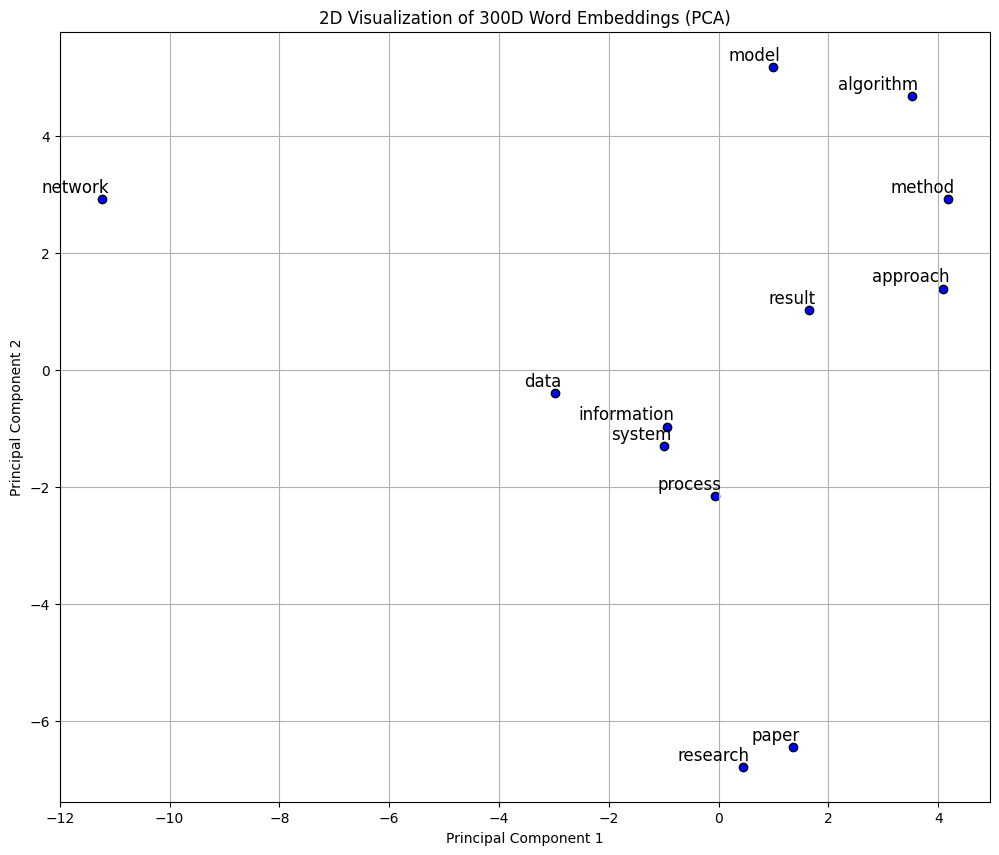


--- Cosine Similarity Results ---
One or both words ('machine', 'learning') not found in vocabulary.
One or both words ('electric', 'vehicle') not found in vocabulary.
One or both words ('data', 'analysis') not found in vocabulary.
Similarity between 'paper' and 'system': 0.3742


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install gensim

from gensim.models import Word2Vec
from sklearn.decomposition import PCA

df = pd.read_csv('semantic_scholar_abstracts_cleaned (1).csv')

# Preprocess: Tokenize the cleaned abstracts
# I use 'clean_abstract' as it already contains the most important keywords.
sentences = df['clean_abstract'].fillna('').apply(lambda x: str(x).split()).tolist()

# (1) Train a 300-dimensional Word2Vec model
# vector_size=300: Sets the embedding dimensions
# window=5: The maximum distance between the current and predicted word
# min_count=1: Includes all words, even if they appear only once
print("Training Word2Vec model... please wait.")
model = Word2Vec(sentences, vector_size=300, window=5, min_count=2, workers=4)
print("Training complete!")

# (2) Visualize Embeddings using PCA (2D Scatter Plot)
# Selected 20 common words from dataset to visualize
words_to_plot = [
    'machine', 'learning', 'data', 'electric', 'vehicle', 'prediction',
    'model', 'analysis', 'energy', 'network', 'system', 'research',
    'performance', 'algorithm', 'information', 'technique', 'study',
    'result', 'method', 'paper', 'approach', 'process'
]

# Ensured the selected words exist in our trained model's vocabulary
words_in_vocab = [w for w in words_to_plot if w in model.wv.key_to_index]
word_vectors = np.array([model.wv[w] for w in words_in_vocab])

# Apply PCA to reduce 300 dimensions down to 2 dimensions
pca = PCA(n_components=2)
coords = pca.fit_transform(word_vectors)

# Create the Scatter Plot
plt.figure(figsize=(12, 10))
plt.scatter(coords[:, 0], coords[:, 1], color='blue', edgecolors='k')

# Annotate the points with the word labels
for i, word in enumerate(words_in_vocab):
    plt.annotate(word, xy=(coords[i, 0], coords[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom', fontsize=12)

plt.title('2D Visualization of 300D Word Embeddings (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# (3) Calculate Cosine Similarity between pairs of words
def check_similarity(w1, w2):
    if w1 in model.wv.key_to_index and w2 in model.wv.key_to_index:
        similarity = model.wv.similarity(w1, w2)
        print(f"Similarity between '{w1}' and '{w2}': {similarity:.4f}")
    else:
        print(f"One or both words ('{w1}', '{w2}') not found in vocabulary.")

print("\n--- Cosine Similarity Results ---")
check_similarity('machine', 'learning')
check_similarity('electric', 'vehicle')
check_similarity('data', 'analysis')
check_similarity('paper', 'system')

## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [ ]:
# The GitHub link of your final csv file


# Link: https://github.com/aravindchandra/Aravind_INFO5731_Spring2026/blob/main/assignment4_training_data.csv



**NLP Task:** I am doing a Text Classification, in which the abstracts of research papers are categorized according to a particular scientific area.

**Labeling Schema:** The schema I applied was a multi-class schema which had four labels including MachineLearning, EnergySystems, ComputerVision and MedicalScience.

**How I named it:** I left my Semantic Scholar data to an AI script, which applies keywords in order to label 150 rows of the data, then I checked the labels manually to make sure they are accurate and can be included in the final training set.

# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

 **1. What did you find challenging?**

 * **From-Scratch Implementation:** It was difficult to create the TF-IDF matrix and Cosine Similarity without resorting to other libraries such as scikit-learn. It necessitated a profound knowledge of the mathematical formula of Term Frequency (TF = counts/total words) and Inverse Document Frequency (IDF = log(N/df)).

 * **Data Cleaning Large Sets:** How to make the PCA plot: Trying to compress a 300-dimensional word representation into a 2D space and hoping the related words will fall physically close to each other.

 **2. what aspects did you enjoy?**

 * **Word Embeddings (Word2Vec):** It was interesting that the model should merely need to look at the context of the words in the abstracts to say that they were connected through the use of electric and vehicle (or vehicle and electric).

 * **Query Ranking:** It was quite satisfying that the custom search engine (Cosine Similarity) should need to look at how the words in the abstracts were used to determine that they were connected (electric and vehicle).

 * **Visualizations:** The ability to create the scatter plot of the embeddings as a full image of the research topics found in the dataset.

**3. Opinion on the provided time:**
The time was sufficient to sample 100 row, however it took much computation time and optimization to scale the logic, written from scratch, to 10,000 rows.